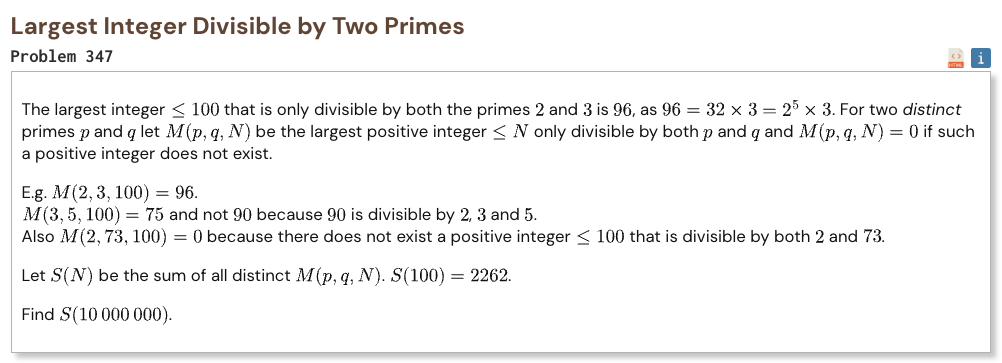

## Initial approach

* generate all primes up to the limit
* only test prime pairs whose product is still below the limit
* for each valid pair, try powers of the first prime
* for each of those, multiply by powers of the second prime
* keep the largest value that uses both primes and stays within the limit
* add that largest value once for each prime pair
* verify the small example before solving the target

In [1]:
import math

def prime_sieve(limit):
    is_prime = bytearray(b"\x01") * (limit + 1)
    is_prime[0] = 0
    is_prime[1] = 0

    for p in range(2, math.isqrt(limit) + 1):
        if is_prime[p]:
            start = p * p
            is_prime[start:limit + 1:p] = b"\x00" * (((limit - start) // p) + 1)

    return [i for i in range(limit + 1) if is_prime[i]]

def M(p, q, limit):
    best = 0
    a = p

    while a * q <= limit:
        b = q

        while a * b <= limit:
            value = a * b

            if value > best:
                best = value

            b *= q

        a *= p

    return best

def S(limit):
    primes = prime_sieve(limit)
    total = 0

    for i, p in enumerate(primes):
        if p * p > limit:
            break

        for q in primes[i + 1:]:
            if p * q > limit:
                break

            total += M(p, q, limit)

    return total

In [2]:
%%time
assert M(2, 3, 100) == 96
assert M(3, 5, 100) == 75
assert M(2, 73, 100) == 0
assert S(100) == 2262
result = S(10_000_000)
print("Result:", result)

Result: 11109800204052
CPU times: user 1.17 s, sys: 106 ms, total: 1.28 s
Wall time: 1.28 s
